In [16]:
import pandas as pd

In [17]:
# Importar o arquivo SaldoMS
SaldoMS = pd.read_excel('SaldoMS.xlsx')

# Converter a coluna Data para o formato de data
SaldoMS['Data'] = pd.to_datetime(SaldoMS['Data'])

# Exibir as primeiras linhas do DataFrame para verificar
print(SaldoMS.head())

        Data  Saldo Sistema Contas  Valor Banco  Diferença
0 2026-01-01             373097.16    373084.35      12.81
1 2026-01-02            1349744.24   1349730.14      14.10
2 2026-01-03            1348816.97   1348802.87      14.10
3 2026-01-04            1348816.97   1348802.87      14.10
4 2026-01-05             918372.21    918357.41      14.80


In [18]:
# Importar o arquivo SaldoSF
SaldoSF = pd.read_excel('SaldoSF.xlsx')

# Converter a coluna Data para o formato de data
SaldoSF['Data'] = pd.to_datetime(SaldoSF['Data'])

# Exibir as primeiras linhas do DataFrame para verificar
print(SaldoSF.head())

        Data      Saldo Final
0 2026-01-01  R$ 1.410.469,48
1 2026-01-02  R$ 1.407.120,83
2 2026-01-03  R$ 1.407.120,83
3 2026-01-04  R$ 1.407.120,83
4 2026-01-05  R$ 1.385.649,14


In [19]:
# Importar o arquivo SaldoSB
SaldoSB = pd.read_excel('SaldoSB.xlsx')

# Converter a coluna Data para o formato de data
SaldoSF['Data'] = pd.to_datetime(SaldoSB['Data'])

# Exibir as primeiras linhas do DataFrame para verificar
print(SaldoSB.head())

        Data  Saldo Sistema Contas  Valor Banco  Diferença
0 2026-01-01            8874092.80   8874083.46       9.34
1 2026-01-02            9827625.03   9827615.69       9.34
2 2026-01-03            9827625.03   9827615.69       9.34
3 2026-01-04            9827625.03   9827615.69       9.34
4 2026-01-05            9649475.71   9649466.37       9.34


<>:17: SyntaxWarning: "\$" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\$"? A raw string is also an option.
<>:17: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<>:17: SyntaxWarning: "\$" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\$"? A raw string is also an option.
<>:17: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
C:\Users\Brener\AppData\Local\Temp\ipykernel_14676\4235792438.py:17: SyntaxWarning: "\$" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\$"? A raw string is also an option.
  .replace({'R\$': '', '\.': '', ',': '.'}, regex=True)
C:\Users\Brener\AppData\Local\Temp\ipykernel_14676\4235792438.py:17: SyntaxWarning: "\." is an invalid escape se

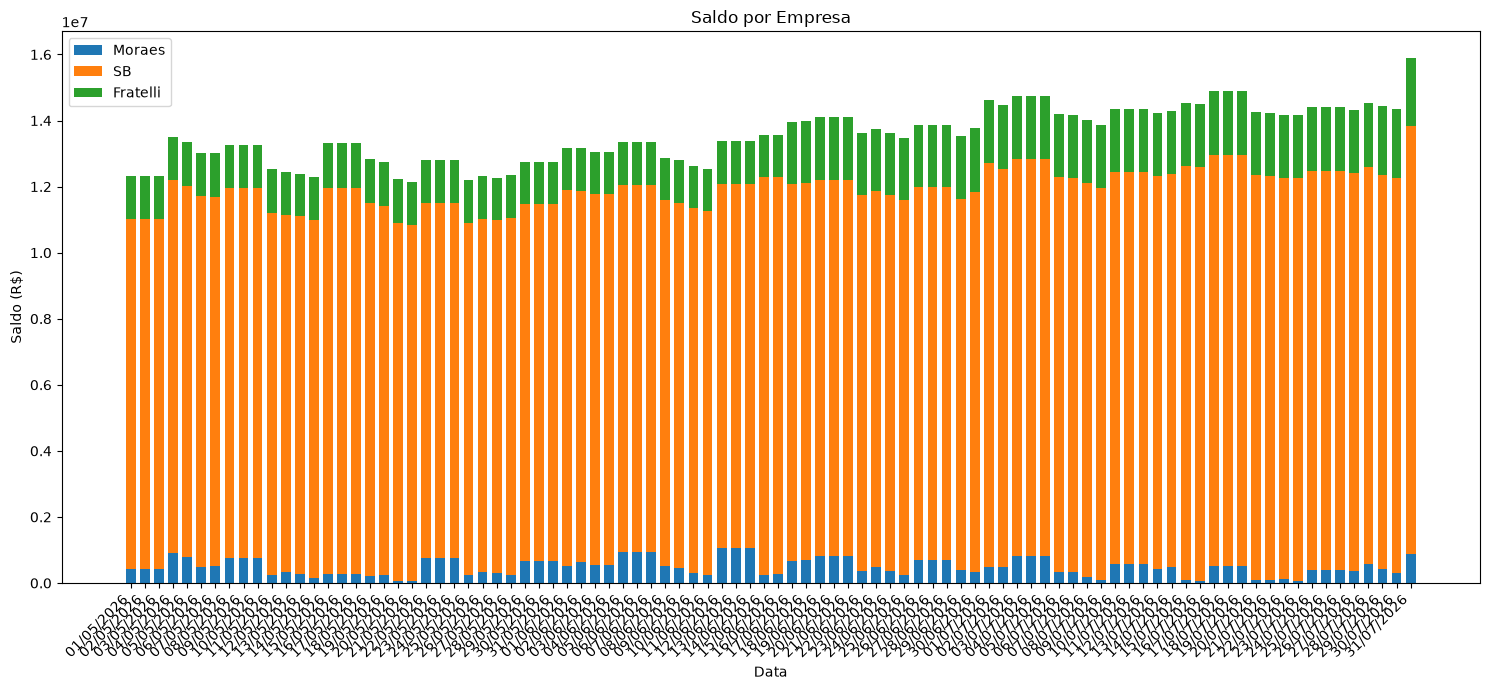

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ==============================
# 1. Tratamento dos dados
# ==============================

SaldoMS['Data'] = pd.to_datetime(SaldoMS['Data'])
SaldoSB['Data'] = pd.to_datetime(SaldoSB['Data'])
SaldoSF['Data'] = pd.to_datetime(SaldoSF['Data'])

# Converter Saldo Final da SF para float
SaldoSF['Saldo Final'] = (
    SaldoSF['Saldo Final']
    .replace({'R\$': '', '\.': '', ',': '.'}, regex=True)
    .astype(float)
)


# ==============================
# 2. Juntar as três empresas
# ==============================

df = pd.merge(
    SaldoMS[['Data', 'Valor Banco']],
    SaldoSB[['Data', 'Valor Banco']],
    on='Data',
    how='outer',
    suffixes=('_MS', '_SB')
)

df = pd.merge(
    df,
    SaldoSF[['Data', 'Saldo Final']],
    on='Data',
    how='outer'
)

df = df.fillna(0)
df = df.sort_values('Data')


# ==============================
# 3. DEFINIR INTERVALO
# ==============================

data_inicio = '2026-05-01'
data_fim = '2026-07-31'

df = df[
    (df['Data'] >= data_inicio) &
    (df['Data'] <= data_fim)
].copy()


# ==============================
# 4. Criar gráfico
# ==============================

x = np.arange(len(df))
width = 0.7

fig, ax = plt.subplots(figsize=(15, 7))

# Moraes
ax.bar(
    x,
    df['Valor Banco_MS'],
    width,
    label='Moraes'
)

# SB
ax.bar(
    x,
    df['Valor Banco_SB'],
    width,
    bottom=df['Valor Banco_MS'],
    label='SB'
)

# Fratelli
ax.bar(
    x,
    df['Saldo Final'],
    width,
    bottom=df['Valor Banco_MS'] + df['Valor Banco_SB'],
    label='Fratelli'
)


# ==============================
# 5. Configurações
# ==============================

ax.set_xlabel('Data')
ax.set_ylabel('Saldo (R$)')
ax.set_title('Saldo por Empresa')

ax.set_xticks(x)
ax.set_xticklabels(
    df['Data'].dt.strftime('%d/%m/%Y'),
    rotation=45,
    ha='right'
)

ax.legend()

plt.tight_layout()
plt.show()